# Analysis Introduction

Urban bike sharing systems produce large amounts of operational data that can be used to improve service planning and operational efficiency. One important operational challenge for bike sharing operators is determining when to perform maintenance on bikes without significantly disrupting customer usage. While maintenance is necessary to ensure safety and reliability, performing it during high demand periods can inconvenience users and reduce system availability. As a result, identifying periods of consistently low demand is critical for scheduling maintenance activities effectively.

This project analyzes Chicago bike rental data to understand the patterns that drive bike usage and to build a predictive model that can identify low demand conditions. The analysis first examines the underlying purpose of bike usage in Chicago. Evidence suggests that most rentals are associated with leisure and exercise activities rather than commuting. This observation is consistent with findings from the Chicago Bicycle User Survey, which reported that recreation accounted for 52 percent of cycling purposes and fitness for 17 percent, while commuting to work represented only 10 percent of trips (Chicago Department of Transportation, 2006).

To predict rental demand, multiple modeling approaches were evaluated. A baseline Linear Regression model achieved a training score of 0.6425 and a testing score of 0.642, indicating stable but moderate predictive performance. However, the model produced a negative prediction rate of 8.59 percent, which highlights its limitations in capturing the nonlinear relationships that often exist in mobility and weather related data.

To address these limitations, a **Decision Tree Regressor** was developed. The regression tree achieved stronger predictive performance, with a training score of 0.7512 and a **testing score of 0.7399**, while maintaining a small train test gap of 0.0113. This indicates good model generalization. In addition to improved performance, the regression tree offers an important advantage for this business problem. Its structure is highly interpretable and clearly shows how factors such as time, temperature, and humidity influence bike rental demand. Because of this **interpretability**, the regression tree was selected as the final model for the analysis.

Using the regression tree, the study identifies conditions under which bike demand is consistently low. These insights allow the company to schedule maintenance activities during periods that minimize disruption to customers while maintaining system reliability and operational efficiency.

-----

# Data Loading

In [1]:
# Importing packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
import sklearn.linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import numpy as np

# specifying a file name
file = "bike_rentals.xlsx"

# reading bike_rentals excel file into Python through pandas
rentals = pd.read_excel(
    io=file,
    usecols=range(1, 15) # omitting ID
)\
.rename(  #Renaming columns
    columns={
    'Month': 'month',
    'Day of Week': 'day_of_week',
    'Hour': 'hour',
    'Temperature': 'temperature',
    'Humidity': 'humidity',
    'Wind Speed': 'wind_speed',
    'Visibility': 'visibility',
    'Dew Point Temperature': 'dew_point_temperature',
    'UV Index': 'uv_index',
    'Rainfall': 'rainfall',
    'Snowfall': 'snowfall',
    'Seasons': 'seasons',
    'Holiday': 'holiday',
    'RENTALS': 'rentals'
})

# Showing output for the first 5 records
rentals.head(n = 5)

,month,day_of_week,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,uv_index,rainfall,snowfall,seasons,holiday,rentals
0,Jan,Sunday,0,-3.2,40,0.5,1358,-14.9,0.00,0.0,0.0,Winter,Yes,221
1,Jan,Sunday,3,-4.0,44,1.0,2000,-14.4,0.00,0.0,0.0,Winter,Yes,130
2,Jan,Sunday,13,2.4,22,2.3,1921,-17.2,1.10,0.0,0.0,Winter,Yes,268
3,Jan,Sunday,16,3.0,28,2.5,1864,-13.7,0.51,0.0,0.0,Winter,Yes,335
4,Jan,Sunday,17,1.8,33,3.3,1913,-12.8,0.18,0.0,0.0,Winter,Yes,299


# Exploratory Data Analysis

In [2]:
# Describing numerical variables - selected only interesting numerical columns
rentals[['visibility', 'snowfall',	'rentals']].describe().loc[['min', '50%', 'mean', 'max']].round(decimals = 2)

,visibility,snowfall,rentals
min,54.00,0.00,9.0
50%,1502.00,0.00,409.0
mean,1343.84,0.07,709.9
max,2000.00,4.10,3734.0


Daily bike **rental** demand shows a right-skewed distribution, due to some days with exceptionally high rental volumes. **Visibility** is generally high with median value of 1502, which supports safe riding conditions. **Snowfall** in Chicago was generally very low, with only a few outlier days recording slightly over 4 inches.



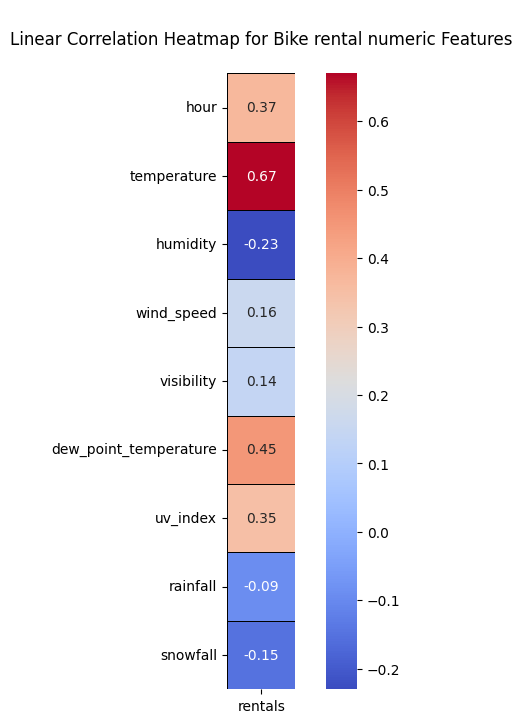

In [3]:
# linear (Pearson) correlation for numeric columns
rentals_corr = rentals.corr(method = 'pearson',
                            numeric_only = True).round(decimals = 2)

# keeping only correlations with rentals
rentals_corr_target = rentals_corr[['rentals']].drop(index='rentals')

# specifying plot size (making it bigger)
fig, ax = plt.subplots( figsize = (8 , 8) )


# developing a coolwarm heatmap
sns.heatmap(data       = rentals_corr_target,
            cmap       = 'coolwarm'   ,
            square     = True         ,
            annot      = True         ,
            linecolor  = 'black'      ,
            linewidths = 0.5          )


# title and displaying the plot
plt.title(label = """
Linear Correlation Heatmap for Bike rental numeric Features
""")


# visualizing the data
plt.show(block = True)

**Temperature, dew point temperature, UV index, wind speed, and visibility** all exhibit a positive relationship with daily bike rental demand. Among these variables, **temperature** shows the strongest correlation with daily rentals, while **visibility** demonstrates the weakest positive association.

# Feature Engineering

## Binary Encoding

In [4]:
# Binary encoding for column holiday to make it numeric
rentals['holiday']=rentals['holiday'].map({
    'Yes': 1,
    'No': 0
})

## Derived Features

In [5]:
# Creating new column hour_period
rentals['hour_period'] = ''

# Iterating through rentals dataframe to categorize hour
for index, col in rentals.iterrows():


    # categorizing 0 - 5 as midnight
    if rentals.loc[index, 'hour'] <= 5:
        rentals.loc[index, 'hour_period'] = 'midnight'

    #categorizing 6 - 11 as morning
    elif rentals.loc[index, 'hour'] <= 11:
        rentals.loc[index, 'hour_period'] = 'morning'

    #categorizing 12 - 17 as noon
    elif rentals.loc[index, 'hour'] <= 17:
        rentals.loc[index, 'hour_period'] = 'noon'

    #categorizing 18 - 23 as night
    elif rentals.loc[index, 'hour'] <= 23:
        rentals.loc[index, 'hour_period'] = 'night'

    # Catching errors if any
    else:
        rentals.loc[index, 'hour_period'] = 'error'

In [6]:
# Creating new column usage_type for estimating bike usage based on day_of_week, hour and holiday
rentals['usage_type'] = ''

# Iterating through rentals dataframe to categorize usage intent
for index, col in rentals.iterrows():

    # Estimating work_commuting bike rental observations
    if ( #Checking Week_days, non holidays and peak hours to categorize observations as work_commuting
        rentals.loc[index, 'day_of_week'] in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
        and rentals.loc[index, 'holiday'] == 0
        and (
            7 <= rentals.loc[index, 'hour'] <= 9  # Between 7 and 9 am inclusive - going to work
            or 16 <= rentals.loc[index, 'hour'] <= 19  # Between 4 and 7 pm inclusive - coming back from work
        )
    ):
        rentals.loc[index, 'usage_type'] = 'work_commuting'

    # Early morning or evening, generally weather-sensitive
    elif (
        rentals.loc[index, 'hour'] <= 7 or rentals.loc[index, 'hour'] >= 19 # Between 7pm and 7am - exercise demand
    ):
        rentals.loc[index, 'usage_type'] = 'exercise'

    # All other observations for midday, weekends and holidays are being treated as leisure
    else:
        rentals.loc[index, 'usage_type'] = 'leisure'


In [7]:
# Reordering columns and filtering out hour and month
rentals = rentals[ ['usage_type', 'day_of_week', 'hour_period', 'temperature', 'humidity', 'wind_speed',
       'visibility', 'dew_point_temperature', 'uv_index', 'rainfall',
       'snowfall', 'rentals'] ]


## Business Question 1

**Question:** Are the majority of rentals for leisure, exercise, or commuting to work?

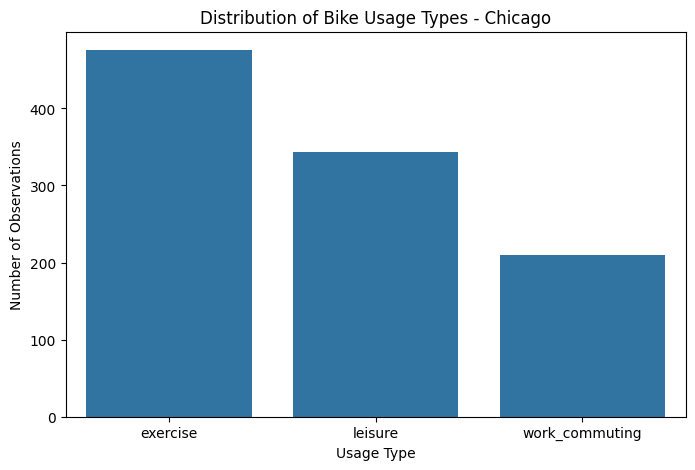

In [8]:
#Are the majority of rentals for leisure, exercise, or commuting to work

usage_counts = rentals['usage_type'].value_counts().reset_index() # Converting series to a dataframe

# Defining Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=usage_counts,
    x='usage_type',
    y='count'
)

plt.title('Distribution of Bike Usage Types - Chicago')
plt.xlabel('Usage Type')
plt.ylabel('Number of Observations')
plt.show()

The majority of bike demand is driven by exercise and leisure activities, with commuting accounting for a smaller share. Consistent with this pattern, the Chicago Bicycle User Survey reported that the primary reasons for cycling were recreation (52%) and fitness (17%), while commuting to work was the least common purpose (10%) (Chicago Department of Transportation, 2006, p. 27).

## Dummy variables

In [9]:
# Creating dummy variables

# one hot encoding for day_of_week
dow_dummies = pd.get_dummies(data   = rentals['day_of_week'],
                          prefix = 'DOW',
                          dtype  = int)

# one hot encoding for hour_period
hour_dummies = pd.get_dummies(data   = rentals['hour_period'],
                          prefix = 'hour',
                          dtype  = int)

# Joining dummy variables with the rest of the dataset
rentals2 = rentals.join([dow_dummies, hour_dummies])

# Feature–target separation

In [10]:
# dropping base dummy variables and some features not usable by the models
rentals = rentals2.drop(['DOW_Saturday', # Making Saturday biking baseline
                           'hour_night', # Making night biking baseline
                          'usage_type',
                          'day_of_week',
                          'hour_period'
                          ], axis = 1)


In [11]:
# Organizing Data for Model Building
## x-side ##
x_all  = rentals.drop(labels = 'rentals', axis = 1)

# Filtering for only weather related columns that important for the model
x_weather = rentals[ ['wind_speed',
                      'dew_point_temperature',
                      'snowfall',
                      'rainfall',
                      'humidity'] ]

# dataframe for linear model
x_compination = rentals[ ['wind_speed',
                           'dew_point_temperature',
                           'snowfall',
                           'rainfall',
                           'humidity',
                           'DOW_Friday',
                           'DOW_Monday',
                           'DOW_Sunday',
                           'DOW_Thursday',
                           'DOW_Tuesday',
                           'DOW_Wednesday',
                           'hour_midnight',
                           'hour_morning',
                           'hour_noon'
                           ] ]

# dataframe for the DecisionTreeRegressor
x_tree = rentals[ ['temperature',
                   'humidity',
                   'uv_index',
                   'hour_midnight',
                   'hour_morning',
                   'DOW_Friday',
                   'DOW_Monday',
                   'DOW_Sunday',
                   'DOW_Thursday',
                   'DOW_Tuesday',
                   'DOW_Wednesday'] ]


## y-side ##
y_original = rentals['rentals']

# Linear Regression Modeling

## Model Input Defination

In [12]:
# Linear regression model input defination
# Training and Testing Sets

# x-data
x_data = x_compination

# y_data
y_data = y_original

# train-test split
x_train, x_test, y_train, y_test = train_test_split(x_data,
                                                    y_data,
                                                    test_size    = 0.35,
                                                    random_state = 702 )

## Model Instantiation & Fitting

In [13]:
# Building Linear Regression Modeling for Chicago bike rentals

# model name
model_name = "Linear Regression"


# INSTANTIATING model object
linear_model = sklearn.linear_model.LinearRegression()


# FITTING to training data
model_fit = linear_model.fit(x_train, y_train)


# PREDICTING on new data
model_pred = linear_model.predict(x_test)


# SCORING results (R-Square)
model_train_score = round(linear_model.score(x_train, y_train), ndigits = 4)
model_test_score  = round(linear_model.score(x_test, y_test), ndigits = 4)
model_gap         = round(model_train_score - model_test_score, ndigits = 4)


# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

# Displaying negative prediction rates
neg_rate = (model_pred < 0).mean()
print(f"Negative prediction rate: {neg_rate:.2%}")

Training Score : 0.6425
Testing Score  : 0.642
Train-Test Gap : 0.0005
Negative prediction rate: 8.59%


# Regression Tree Modeling

## Model Input Defination

In [14]:
# Regression Tree model input defination
# x-data
x_data = x_tree

# y_data
y_data = y_original


# train-test split
x_train, x_test, y_train, y_test = train_test_split(x_data,
                                          y_data,
                                          test_size = 0.35,
                                          random_state = 702)

## Model Instantiation & Fitting

In [15]:
# Buiding Regression Tree model for Chicago bike rentals

# model name
model_name = 'Regression Tree'

# INSTANTIATING a model object - CHANGE THIS AS NEEDED
tree_model = DecisionTreeRegressor(max_depth = 5,
                              min_samples_leaf=15,
                              random_state = 702)


# FITTING to the training data
model_fit = tree_model.fit(x_train, y_train)


# SCORING the results
model_train_score = round(tree_model.score(x_train, y_train), ndigits=4)
model_test_score  = round(tree_model.score(x_test, y_test), ndigits=4)
model_gap         = round(abs(model_train_score - model_test_score),ndigits=4)


# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.7512
Testing Score  : 0.7399
Train-Test Gap : 0.0113


## Business Question 2

**Question:** When is bike demand low enough for the company to perform maintenance without significantly affecting customers?

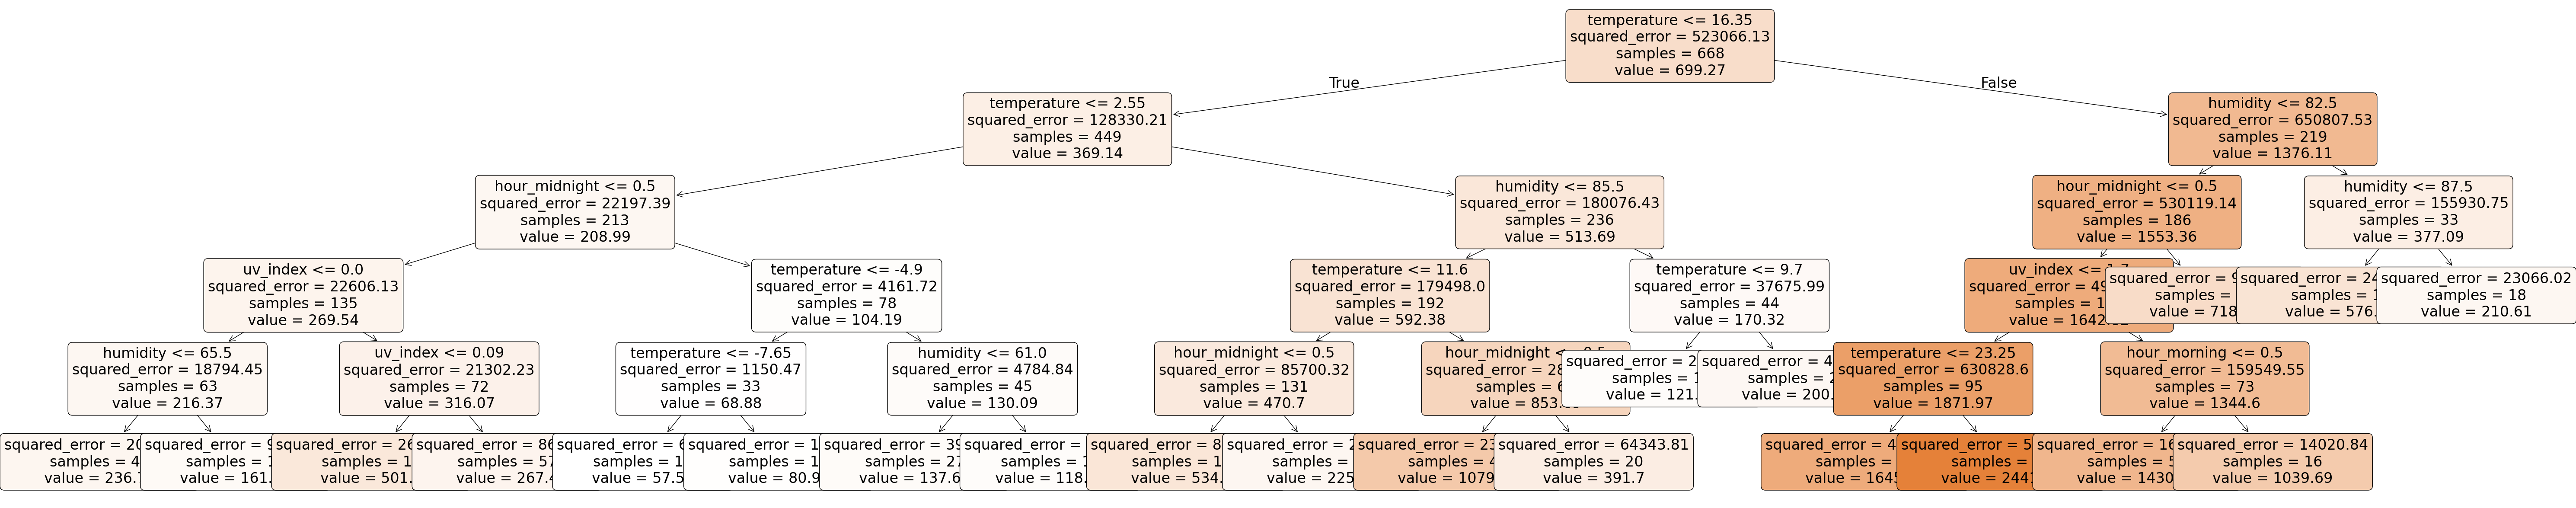

In [16]:
# setting figure size
plt.figure(figsize=(75, 15))


# developing a plotted tree
plot_tree(decision_tree = tree_model,
          feature_names = x_train.columns,
          filled        = True,
          rounded       = True,
          fontsize      = 24,
          precision     = 2)

# rendering the plot
plt.show()

The best time for maintenance is during midnight hours (00:00-05:00). For major maintenance that inconveniences customers, conditions are most suitable when the temperature is below -8, during which average bike demand drops to around 58, indicating very low usage. Major maintenance can also be carried out when the temperature is below -5; however, demand varies, averaging 58 when temperatures are below -8 and 81 when temperatures are between -8 and -5.
Minor maintenance can be conducted when temperatures are above -5 but below 3. Under these conditions, average demand is 138 when humidity is below 61, and 119 when humidity is above this level.
When it is not midnight; that is, during the early morning after 5:00 am before sunrise or the early evening after sunset; minor maintenance may still be performed. During these periods, average bike demand is about 236 when humidity is below 66, and 161 when humidity is above this threshold.




# References
Biking in Chicago during the dead of winter: It's easier than you might think - Streetsblog Chicago. (2025, January 26). Retrieved December 14, 2025, from https://chi.streetsblog.org/2025/01/23/biking-in-chicago-during-the-dead-of-winter-its-easier-that-you-might-think

Chm_Admin. (2024, August 30). The Blizzard of 1967 - Chicago History Museum. Chicago History Museum. https://www.chicagohistory.org/1967blizzard/   

Chicago Department of Transportation. (2006, January). Chicago bicycle user survey. City of Chicago.
https://www.chicago.gov/content/dam/city/depts/cdot/bicycling/publications/cdot_bicycle_survey.pdf
